In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.preprocessing import normalize

df = pd.read_csv('../../../data/komdigi_hoaks.csv')

df['teks'] = df['title'].fillna('') + ' ' + df['excerpt'].fillna('')
df = df[df['teks'].str.strip() != ''].reset_index(drop=True)

print("Total data hoaks:", len(df))
df[['title', 'teks']].head()


Total data hoaks: 4176


,title,teks
0,[HOAKS] Tautan Pencairan BSU September 2026 Se...,[HOAKS] Tautan Pencairan BSU September 2026 Se...
1,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...
2,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...
3,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...
4,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...


In [104]:
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['teks'])

X_cosine = normalize(X, norm='l2')

print("Bentuk matriks data:", X_cosine.shape)

Bentuk matriks data: (4176, 1000)


| Kolom                             | Digunakan? | Keterangan                                                    |
| --------------------------------- | ---------- | ------------------------------------------------------------- |
| `title`                           | ✅          | Judul berita/hoaks                                            |
| `excerpt`                         | ✅          | Ringkasan/potongan isi berita                                 |
| `teks`                            | ✅          | Hasil gabungan `title + excerpt`, menjadi input preprocessing |
| Kolom ID/tanggal/kategori lainnya | ❌          | Tidak diperlukan untuk preprocessing teks                     |


In [105]:
df['teks_bersih'] = df['teks'].fillna('').astype(str)
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['teks_bersih'])

print("Ukuran matriks TF-IDF:", X.shape)

Ukuran matriks TF-IDF: (4176, 8206)


K = 2 → Inertia = 4056.8354
K = 3 → Inertia = 4020.3272
K = 4 → Inertia = 4000.6012
K = 5 → Inertia = 3976.3995
K = 6 → Inertia = 3957.2782
K = 7 → Inertia = 3946.6784
K = 8 → Inertia = 3931.5935
K = 9 → Inertia = 3906.4703
K = 10 → Inertia = 3900.7078


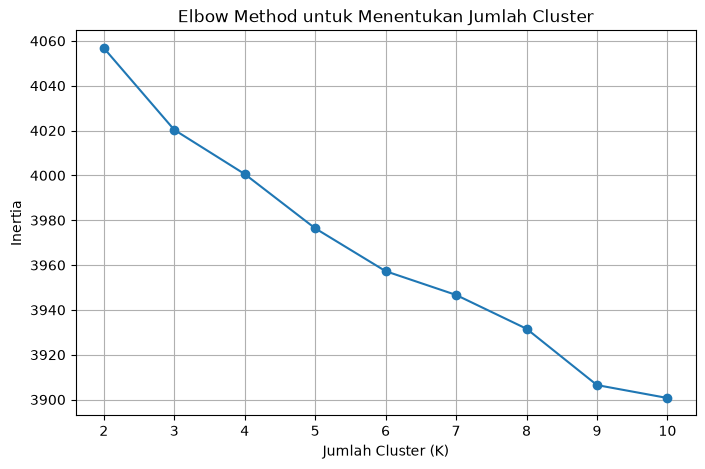

In [106]:
# ============================================================
# ELBOW METHOD
# ============================================================

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Menyimpan nilai inertia
inertia = []

# Mencoba jumlah cluster dari 2 sampai 10
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    
    # Menyimpan inertia
    inertia.append(kmeans.inertia_)


# ============================================================
# MENAMPILKAN NILAI INERTIA
# ============================================================

for k, nilai in zip(K_range, inertia):
    print(f"K = {k} → Inertia = {nilai:.4f}")


# ============================================================
# VISUALISASI ELBOW
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster')

plt.xticks(K_range)
plt.grid(True)

plt.show()

In [107]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X)
centroids = kmeans.cluster_centers_

print("Bentuk centroid:", centroids.shape)

Bentuk centroid: (3, 8206)


In [108]:
from sklearn.metrics import pairwise_distances

euclidean_dist = pairwise_distances(
    X,
    centroids,
    metric='euclidean'
)

print("Bentuk matriks jarak:", euclidean_dist.shape)

Bentuk matriks jarak: (4176, 3)


In [109]:
distance_df = pd.DataFrame(
    euclidean_dist,
    columns=['Distance_C0', 'Distance_C1', 'Distance_C2']
)

distance_df.head()

,Distance_C0,Distance_C1,Distance_C2
0,1.005955,0.995708,1.046725
1,1.034780,0.995411,1.049627
2,1.034179,0.996391,1.050459
3,1.039011,0.997351,1.051623
4,0.978207,0.989964,1.047283


In [110]:
distance_df['Min_Distance'] = distance_df.min(axis=1)
distance_df['Cluster'] = distance_df[
    ['Distance_C0', 'Distance_C1', 'Distance_C2']
].idxmin(axis=1)


In [111]:
distance_df['Cluster'] = (
    distance_df['Cluster']
    .str.replace('Distance_C', '')
    .astype(int)
)

In [112]:
df['cluster'] = distance_df['Cluster']

In [113]:
hasil_euclidean = pd.concat(
    [
        df[['title', 'teks']],
        distance_df
    ],
    axis=1
)

hasil_euclidean.head(10)

,title,teks,Distance_C0,Distance_C1,Distance_C2,Min_Distance,Cluster
0,[HOAKS] Tautan Pencairan BSU September 2026 Se...,[HOAKS] Tautan Pencairan BSU September 2026 Se...,1.005955,0.995708,1.046725,0.995708,1
1,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,1.034780,0.995411,1.049627,0.995411,1
2,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,1.034179,0.996391,1.050459,0.996391,1
3,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,1.039011,0.997351,1.051623,0.997351,1
4,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,0.978207,0.989964,1.047283,0.978207,0
5,[HOAKS] Tautan Aktivasi Kartu ATM SeaBank,[HOAKS] Tautan Aktivasi Kartu ATM SeaBank,0.998127,1.002629,1.051787,0.998127,0
6,[HOAKS] Kemendikbud Bakal Melarang Guru Punya ...,[HOAKS] Kemendikbud Bakal Melarang Guru Punya ...,1.032690,0.996606,1.050519,0.996606,1
7,[HOAKS] Menteri ESDM Bahlil Lahadalia akan Nai...,[HOAKS] Menteri ESDM Bahlil Lahadalia akan Nai...,1.031007,0.990264,1.050579,0.990264,1
8,[HOAKS] Purbaya Jadi Ketua KPK Usai Dicopot da...,[HOAKS] Purbaya Jadi Ketua KPK Usai Dicopot da...,1.027634,0.987774,1.046641,0.987774,1
9,[HOAKS] Pendaftaran Dana Bantuan dari Tom Lembong,[HOAKS] Pendaftaran Dana Bantuan dari Tom Lemb...,1.019416,0.988143,1.050553,0.988143,1


Bentuk data setelah PCA: (4176, 2)
Bentuk centroid setelah PCA: (3, 2)


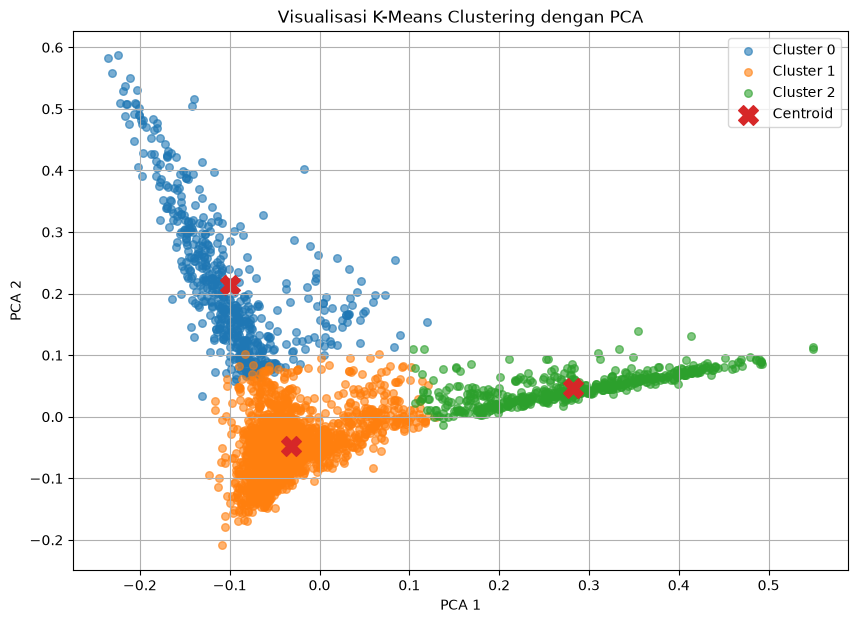

In [114]:
# ============================================================
# VISUALISASI HASIL CLUSTERING DENGAN PCA
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Mengubah data TF-IDF menjadi 2 dimensi
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X.toarray())

# Mengubah centroid ke 2 dimensi yang sama
centroids_pca = pca.transform(centroids)

print("Bentuk data setelah PCA:", X_pca.shape)
print("Bentuk centroid setelah PCA:", centroids_pca.shape)


# ------------------------------------------------------------
# 2. Visualisasi data berdasarkan cluster
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for cluster in range(3):
    cluster_data = X_pca[df['cluster'].values == cluster]

    plt.scatter(
        cluster_data[:, 0],
        cluster_data[:, 1],
        label=f'Cluster {cluster}',
        alpha=0.6,
        s=30
    )


# ------------------------------------------------------------
# 3. Visualisasi centroid
# ------------------------------------------------------------

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=200,
    label='Centroid'
)


# ------------------------------------------------------------
# 4. Label dan judul
# ------------------------------------------------------------

plt.title('Visualisasi K-Means Clustering dengan PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# PENGUJIAN K-MEANS
# Jumlah Cluster, Waktu Eksekusi, Silhouette Score,
# dan Penggunaan Memori
# ============================================================

import time
import tracemalloc


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# 1. MULAI PENGUKURAN
# ============================================================

K = 3

tracemalloc.start()
start_time = time.perf_counter()


# ============================================================
# 2. PROSES K-MEANS
# ============================================================

kmeans_test = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_test.fit_predict(X)


# ============================================================
# 3. WAKTU EKSEKUSI
# ============================================================

end_time = time.perf_counter()

execution_time = end_time - start_time


# ============================================================
# 4. PENGGUNAAN MEMORI
# ============================================================

current_memory, peak_memory = tracemalloc.get_traced_memory()

tracemalloc.stop()

memory_mb = peak_memory / (1024 ** 2)


# ============================================================
# 5. SILHOUETTE SCORE
# ============================================================

silhouette = silhouette_score(
    X,
    cluster_labels
)


# ============================================================
# 6. MENAMPILKAN HASIL
# ============================================================

print("==========================================")
print("HASIL PENGUJIAN K-MEANS Euclidean_Distance")
print("==========================================")

print(f"Jumlah data       : {X.shape[0]}")
print(f"Jumlah fitur      : {X.shape[1]}")
print(f"Jumlah cluster    : {K}")
print(f"Waktu eksekusi    : {execution_time:.4f} detik")
print(f"Silhouette Score  : {silhouette:.4f}")
print(f"Peak Memory       : {memory_mb:.2f} MB")

HASIL PENGUJIAN K-MEANS
Jumlah data       : 4176
Jumlah fitur      : 8206
Jumlah cluster    : 3
Waktu eksekusi    : 0.1604 detik
Silhouette Score  : 0.0113
Peak Memory       : 2.66 MB
